
| Course   | ATU - Applied Statistics  |
|----------|----------|
| Project  | Applied Statistics Course Project  |
| Date     | 2026-09-21  |
| Instructor | Dr. Ian McLoughlin  |
| Author  | Clyde Watts  |



### Problem 0: Project Initialization

This will load the necessary libraries and initialize the project environment.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Need norm for normal distribution
from scipy.stats import norm

In [4]:
# Globals

# File path for Iris Data Set
IRIS_CSV = "data/iris.csv"

In [5]:
# Load into pandas dataframe
iris_df = pd.read_csv(IRIS_CSV)
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Problem 1: Exploring Petal Length

The [Iris dataset](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv) contains measurements of 150 iris flowers belonging to three species: `setosa`, `versicolor`, and `virginica`.
For each flower, the dataset records sepal length, sepal width, petal length, and petal width.

Using the Iris dataset, investigate the distribution of `petal_length`.

1. Plot a histogram showing the petal lengths of all 150 flowers.
2. On the same plot, superimpose an appropriate normal distribution, using the mean and standard deviation calculated from the data.
3. Create separate histograms for each of the three species, and superimpose an appropriate normal distribution on each.
4. Report the mean and standard deviation of petal length for the complete dataset and for each species.
5. Describe and compare the distributions you observe. In particular, discuss whether a normal distribution appears to be a reasonable model for petal length overall and within each species.


#### 1.1: Plot a histogram of the petal lengths of all 150 flowers

Plot the histogram of the petal lengths using seaborn's histplot function.

The histogram plot shows two distinct distributions, indicating that there are two groups of petal lengths among the 150 flowers. The one group is between 1 and 2 units in length, while the other group is between 4 and 6 units in length.

Reference:
Seaborn histplot documentation: https://seaborn.pydata.org/generated/seaborn.histplot.html

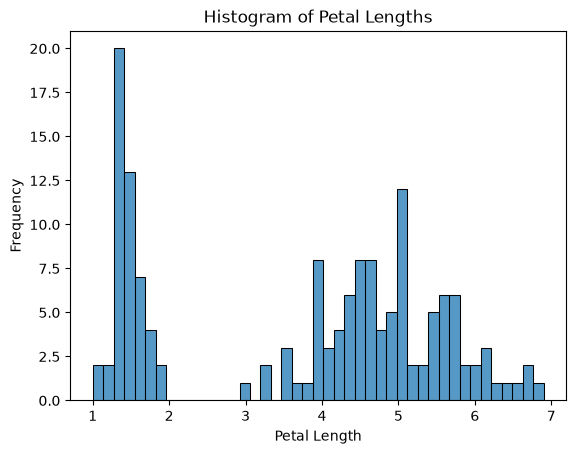

In [15]:
# 1.1: Histogram of Petal Lengths
ax = sns.histplot(iris_df['petal_length'],bins=43)
ax.set_title("Histogram of Petal Lengths")
ax.set_xlabel("Petal Length")
ax.set_ylabel("Frequency")
plt.show()

#### 1.2: On the same plot, superimpose an appropriate normal distribution, using the mean and standard deviation calculated from the data.

Normal distribution formula:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
where 
\(\mu\) is the mean of the distribution and \(\sigma\) is the standard deviation.

Probability density function (PDF) or Standard normal curve helps to visualize how the data would be distributed if it followed a normal distribution.


The PDF shows the ideal distribution of the data if it would follow a normal distribution. In the case when this plot where each of the 3 species of iris flowers are plotted as one plot the normal distribution curve of the data , and the histogram shows a discrepency between the expected distribution , and the actuall data . This is because this is the combined data of three difference species and each species has its own mean and standard deviation, causing the overall distribution to deviate from a single normal distribution.






Mean: 3.7580000000000005, Standard Deviation: 1.7652982332594662


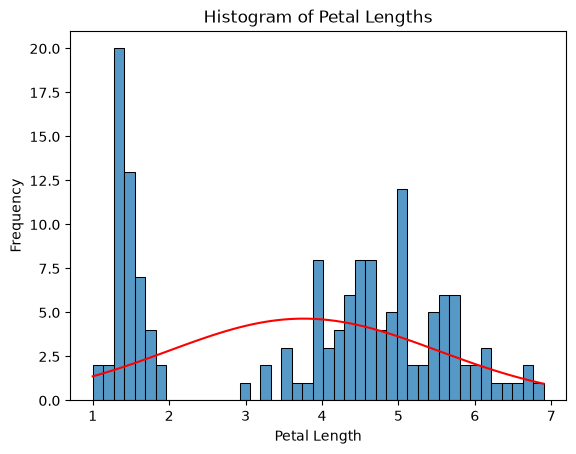

In [20]:
# 1.2 : Histogram of Petal Lengths
ax = sns.histplot(iris_df['petal_length'],bins=43,)
ax.set_title("Histogram of Petal Lengths")
ax.set_xlabel("Petal Length")
ax.set_ylabel("Frequency")
# For a normal distribution we need the mean and standard deviation
mean = iris_df['petal_length'].mean()
std = iris_df['petal_length'].std()
print(f"Mean: {mean}, Standard Deviation: {std}")



x = np.linspace(iris_df['petal_length'].min(), iris_df['petal_length'].max(), 100)
# probability density function - given x , and mean and standard deviation
# y contains the values of the normal distribution at each point in x
# shows what it should be if the data set followed a normal distribution
y = norm.pdf(x, mean, std)
plt.plot(x, y * len(iris_df['petal_length']) * (iris_df['petal_length'].max() - iris_df['petal_length'].min()) / 43, color='red')
plt.show()

###    1.3. Create separate histograms for each of the three species, and superimpose an appropriate normal distribution on each.

C:\Users\cw171001\AppData\Local\Temp\ipykernel_30896\2906367585.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


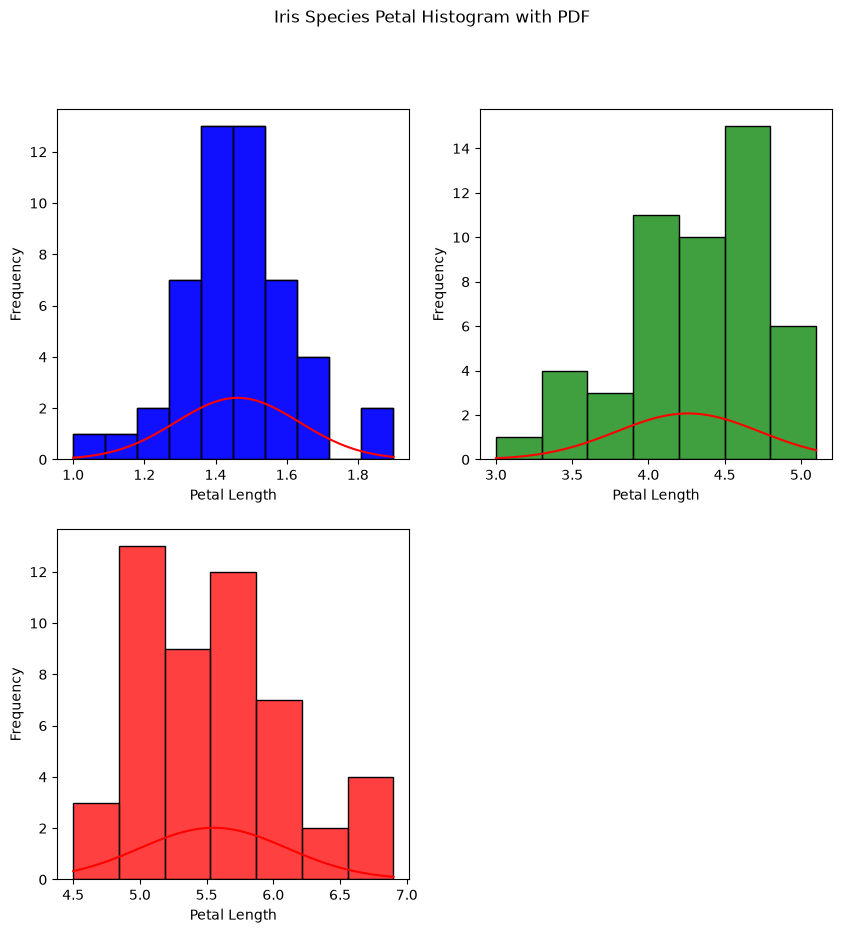

In [33]:
# The three species are setosa, versicolor, and virginica
df_setosa = iris_df[iris_df['species'] == 'setosa']
df_versicolor = iris_df[iris_df['species'] == 'versicolor']
df_virginica = iris_df[iris_df['species'] == 'virginica']
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
# Set the title of the figure
fig.suptitle('Iris Species Petal Histogram with PDF')
# loop through the features and plot the histogram for each feature
# learned this from datacamp course - after doing the below
axflat = ax.flatten()
# Plot histograms for each species
sns.histplot(df_setosa['petal_length'],ax=axflat[0], color='blue')   
axflat[0].set_xlabel("Petal Length")
axflat[0].set_ylabel("Frequency")
# For a normal distribution we need the mean and standard deviation
sns.histplot(df_setosa['petal_length'],ax=axflat[0], color='blue')   
mean_setosa = df_setosa['petal_length'].mean()
std_setosa = df_setosa['petal_length'].std()
x = np.linspace(df_setosa['petal_length'].min(), df_setosa['petal_length'].max(), 100)
y = norm.pdf(x, mean_setosa, std_setosa)
axflat[0].plot(x, y * len(df_setosa['petal_length']) * (df_setosa['petal_length'].max() - df_setosa['petal_length'].min()) / 43, color='red')

sns.histplot(df_versicolor['petal_length'], ax=axflat[1], color='green')
axflat[1].set_xlabel("Petal Length")
axflat[1].set_ylabel("Frequency")
mean_versicolor = df_versicolor['petal_length'].mean()
std_versicolor = df_versicolor['petal_length'].std()
x = np.linspace(df_versicolor['petal_length'].min(), df_versicolor['petal_length'].max(), 100)
y = norm.pdf(x, mean_versicolor, std_versicolor)
axflat[1].plot(x, y * len(df_versicolor['petal_length']) * (df_versicolor['petal_length'].max() - df_versicolor['petal_length'].min()) / 43, color='red')

sns.histplot(df_virginica['petal_length'], ax=axflat[2], color='red')
axflat[2].set_xlabel("Petal Length")
axflat[2].set_ylabel("Frequency")
mean_virginica = df_virginica['petal_length'].mean()
std_virginica = df_virginica['petal_length'].std()
x = np.linspace(df_virginica['petal_length'].min(), df_virginica['petal_length'].max(), 100)
y = norm.pdf(x, mean_virginica, std_virginica)
axflat[2].plot(x, y * len(df_virginica['petal_length']) * (df_virginica['petal_length'].max() - df_virginica['petal_length'].min()) / 43, color='red')
# Hide the unused subplot
axflat[3].axis('off')

fig.show()

### Problem 2: Correlation Between Petal Length and Petal Width

Investigate the relationship between `petal_length` and `petal_width` in the Iris dataset.

1. Calculate the Pearson correlation coefficient between petal length and petal width using all 150 flowers.
2. Create an appropriate scatter plot showing the relationship between the two variables, and include a suitable line to help illustrate the relationship.
3. Calculate the Pearson correlation coefficient separately for each of the three species.
4. Create an appropriate plot showing the relationship between petal length and petal width for each species.
5. Report and compare the correlation coefficients.
6. Explain what the correlation coefficients tell you about the relationship between petal length and petal width, both for the dataset as a whole and within each species.

### Problem 3: Comparing Species Using t-Tests

Investigate whether the three iris species differ in their `petal_length` and `petal_width`.

For each pair of species:

- `setosa` vs `versicolor`
- `setosa` vs `virginica`
- `versicolor` vs `virginica`

perform an independent-samples t-test for:

- petal length,
- petal width.

For each test:

1. State the null and alternative hypotheses.
2. Calculate the t-statistic and p-value using `scipy.stats`.
3. Use a significance level of $\alpha=0.05$ to decide whether to reject the null hypothesis.
4. Summarise your results in an appropriate table.
5. Explain what the results tell you about differences between the three species.